In [20]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np

import seaborn as sns
sns.set_theme(style="darkgrid")
import plotly.express as px

In [2]:
root_dir = Path(".").resolve().parents[1] 
data_path = (
    root_dir 
    / "data" 
    / "station_instrumentation" 
    / "climate"
)
print(data_path)
weather_raw = pd.read_csv(data_path / "Weather_2010_2025_10min_SagehenTower1.csv")

C:\Users\Owner\OneDrive\Desktop\SAGEHEN MEADOWS\sagehen_meadows\data\station_instrumentation\climate


In [3]:
### Functions for calculating VPD transcribed from the R package 'plantecophys'
# Will move to separate python file in future

def esat(TdegC, Pa=101):
    """
    TdegC : temperature (C)
    Pa : atmospheric pressure (kPa)
    """
    a = 611.21
    b = 17.502
    c = 240.97
    f = 1.0007 + 3.46 * (10 ** -8) * Pa * 1000
    esatval = f * a * (np.exp(b * TdegC / (c + TdegC)))    
    return esatval
    
def RH_to_VPD(RH, TdegC, Pa=101):
    """
    RH : relative humidity (%)
    TdegC : temperature (C)
    Pa : atmospheric pressure (kPa)
    """
    esatval = esat(TdegC, Pa)
    e = (RH / 100) * esatval
    VPD = (esatval - e) / 1000
    return VPD

In [57]:
selected_columns = ['time', 'air-temp-avg-degc', 'relative-humidity-avg-pct']
renamed_columns = {'air-temp-avg-degc':'TdegC', 'relative-humidity-avg-pct':'RH'}

weather = weather_raw[selected_columns].rename(renamed_columns, axis='columns')
weather['time'] = pd.to_datetime(weather['time'], format="%m/%d/%y %H:%M")
weather['date'] = weather['time'].apply(lambda val: val.strftime('%Y-%m-%d'))

weather.sample(5)

,time,TdegC,RH,date
13008,2020-03-31 08:00:00,3.511,82.70,2020-03-31
160446,2023-01-19 05:00:00,-7.822,87.80,2023-01-19
293998,2025-08-06 10:30:00,23.140,18.97,2025-08-06
173593,2023-04-22 23:10:00,0.021,87.70,2023-04-22
148629,2022-10-29 03:30:00,-4.918,73.95,2022-10-29


In [58]:
# First approach: calculate average temperature and RH by date
daily_avg_approach = weather.groupby('date', as_index=False).agg(avgT=('TdegC', 'mean'), avgRH=('RH', 'mean'))
# Calculate VPD based on daily averages
daily_avg_approach['vpd'] = daily_avg_approach.apply(lambda row: RH_to_VPD(row['avgRH'], row['avgT']), axis=1)
daily_avg_approach['rolling_avg'] = daily_avg_approach['vpd'].rolling(window=90).mean()
daily_avg_approach

,date,avgT,avgRH,vpd,rolling_avg
0,2020-01-01,0.471882,79.032083,0.133174,NaN
1,2020-01-02,-1.739660,78.365417,0.116918,NaN
2,2020-01-03,1.925118,58.083819,0.295552,NaN
3,2020-01-04,2.486681,62.236458,0.277152,NaN
4,2020-01-05,-1.912688,65.806042,0.182449,NaN
...,...,...,...,...,...
2135,2025-11-06,5.409139,85.230208,0.133125,0.420336
2136,2025-11-07,5.169417,89.004236,0.097470,0.410730
2137,2025-11-08,4.113604,87.267292,0.104836,0.399742
2138,2025-11-09,4.883111,86.934653,0.113527,0.388137


In [59]:
# Second approach: calculate VPD per observation, then take statistics by date
observation_approach = weather.copy()
observation_approach['vpd'] = observation_approach.apply(lambda row: RH_to_VPD(row['RH'], row['TdegC']), axis=1)
observation_approach = observation_approach.groupby('date', as_index=False).agg(min_vpd=('vpd', 'min'), max_vpd=('vpd', 'max'), avg_vpd=('vpd', 'mean'))
observation_approach['rolling_avg'] = observation_approach['avg_vpd'].rolling(window=90).mean()

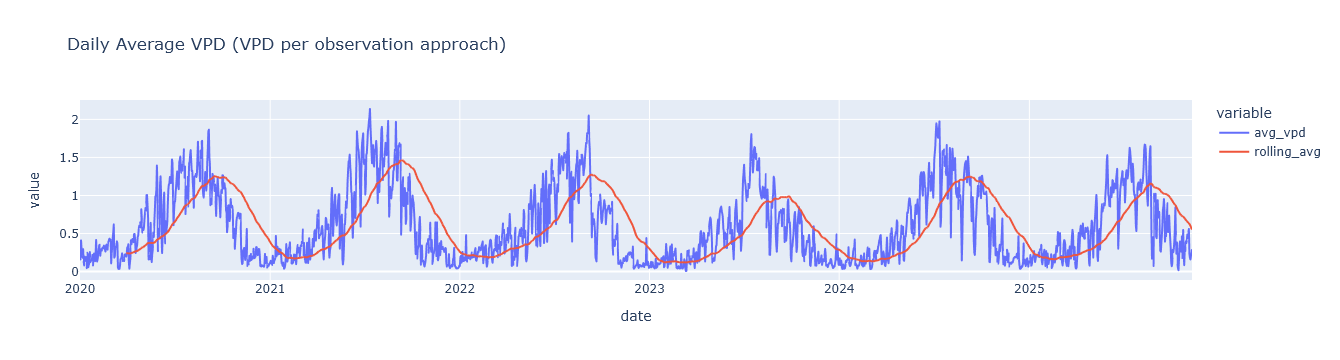

In [60]:
px.line(observation_approach, x='date', y=['avg_vpd', 'rolling_avg'], title="Daily Average VPD (VPD per observation approach)")

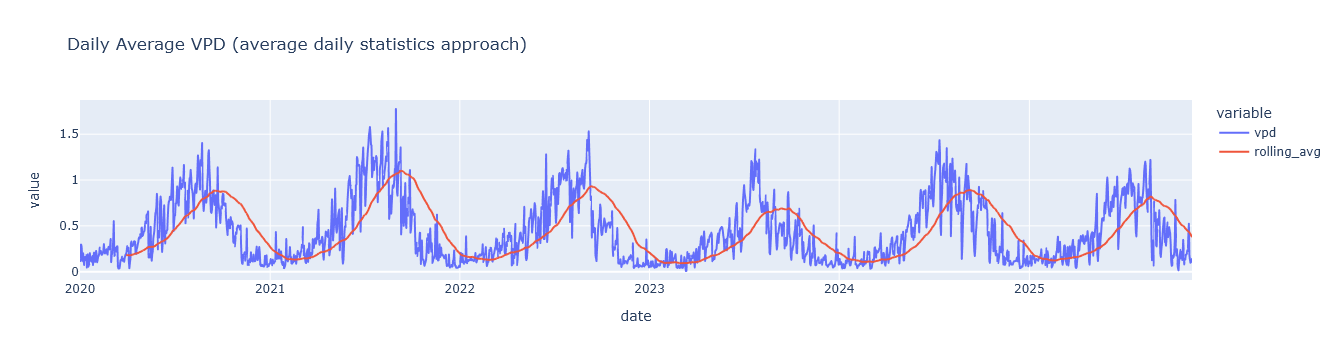

In [61]:
px.line(daily_avg_approach, x='date', y=['vpd', 'rolling_avg'], title="Daily Average VPD (average daily statistics approach)")

In [64]:
merged = pd.DataFrame(daily_avg_approach['date'])
merged = merged.join(daily_avg_approach['rolling_avg']).rename({'rolling_avg':'daily_avg_approach'}, axis='columns')
merged = merged.join(observation_approach['rolling_avg']).rename({'rolling_avg':'observation_approach'}, axis='columns')
merged

,date,daily_avg_approach,observation_approach
0,2020-01-01,NaN,NaN
1,2020-01-02,NaN,NaN
2,2020-01-03,NaN,NaN
3,2020-01-04,NaN,NaN
4,2020-01-05,NaN,NaN
...,...,...,...
2135,2025-11-06,0.420336,0.613311
2136,2025-11-07,0.410730,0.599640
2137,2025-11-08,0.399742,0.584124
2138,2025-11-09,0.388137,0.568211


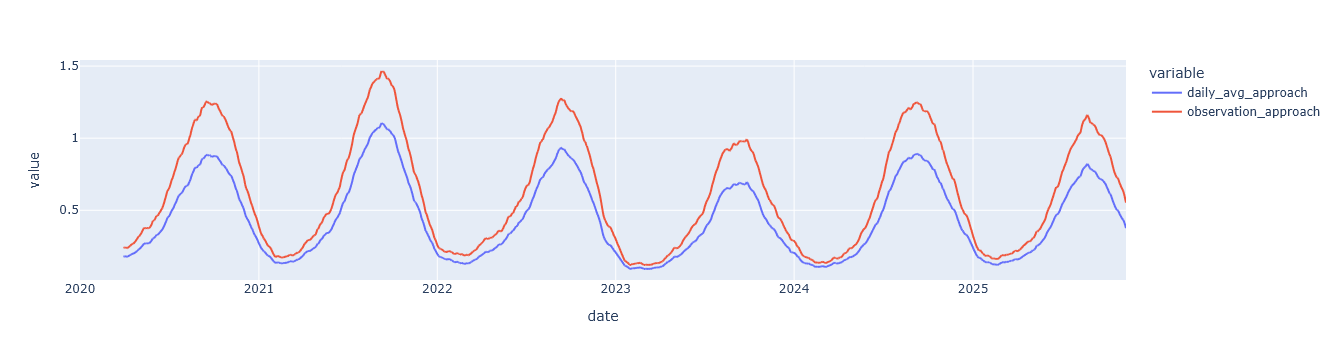

In [67]:
px.line(merged, x='date', y=['daily_avg_approach', 'observation_approach'])